Часть 2. Марковские цепи.  CpG islands детектор

In [2]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.9 MB/s eta 0:00:00


Длина анализируемой последовательности: 100000
Найдено участков-кандидатов: 48
  Начало: 10300, R(CG)=1.015, GC%=59.5%
  Начало: 10350, R(CG)=0.752, GC%=58.0%
  Начало: 10400, R(CG)=0.798, GC%=61.5%
  Начало: 10450, R(CG)=0.990, GC%=67.5%
  Начало: 10500, R(CG)=1.173, GC%=70.5%


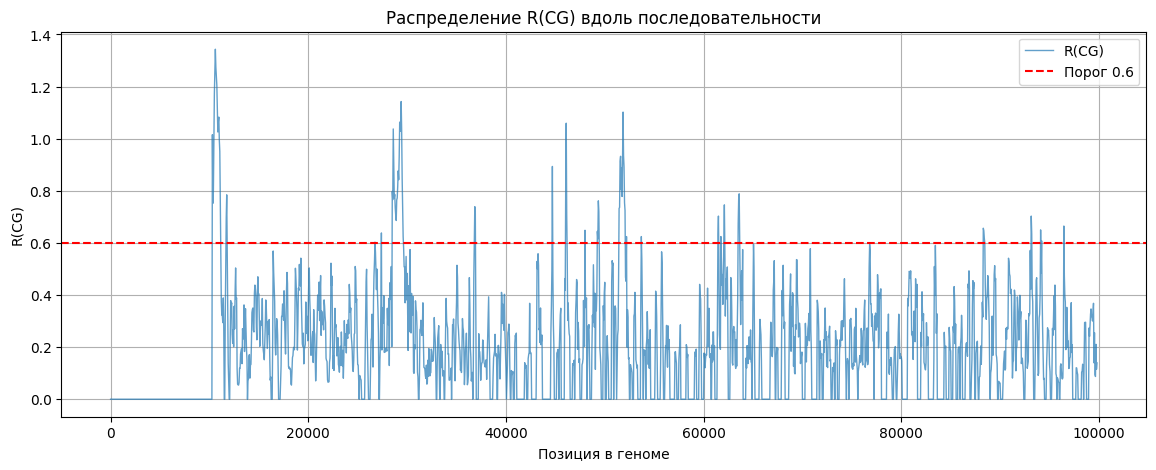

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO

import os
import urllib.request
import gzip
import shutil

fa_filename = "chr1.fa"
if not os.path.exists(fa_filename):

    url = "http://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr1.fa.gz"
    gz_filename = "chr1.fa.gz"

    urllib.request.urlretrieve(url, gz_filename)

    with gzip.open(gz_filename, 'rb') as f_in:
        with open(fa_filename, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    os.remove(gz_filename)



def load_chromosome_part(filename="chr1.fa", length=100000):
    """Загружает первые length нуклеотидов из FASTA-файла."""
    try:
        record = SeqIO.read(filename, "fasta")
        seq = str(record.seq)[:length].upper()
        return seq
    except FileNotFoundError:
        raise FileNotFoundError(f"Файл {filename} не найден. Убедитесь, что он загружен.")


seq = load_chromosome_part()
print("Длина анализируемой последовательности:", len(seq))

# Функция compute_cpg_ratio
def compute_cpg_ratio(window):
    """ window - строка из нуклеотидов """
    if len(window) == 0:
        return 0.0, 0.0
    cg_count = 0
    for i in range(len(window)-1):
        if window[i] == 'C' and window[i+1] == 'G':
            cg_count += 1
    p_cg = cg_count / (len(window)-1) if len(window) > 1 else 0.0
    # частоты отдельных нуклеотидов
    c_freq = window.count('C') / len(window)
    g_freq = window.count('G') / len(window)
    # Ожидаемая частота CG при независимости
    expected_cg = c_freq * g_freq
    r_cg = p_cg / expected_cg if expected_cg > 0 else 0.0
    gc_percent = (c_freq + g_freq) * 100.0
    return r_cg, gc_percent

# Сканирование скользящим окном 200
window_size = 200
step = 50
positions = []
r_cg_values = []
gc_values = []
for start in range(0, len(seq) - window_size + 1, step):
    win = seq[start:start+window_size]
    r, gc = compute_cpg_ratio(win)
    positions.append(start)
    r_cg_values.append(r)
    gc_values.append(gc)

positions = np.array(positions)
r_cg_values = np.array(r_cg_values)
gc_values = np.array(gc_values)


islands = (r_cg_values > 0.6) & (gc_values > 50)
island_starts = positions[islands]
print(f"Найдено участков-кандидатов: {len(island_starts)}")
if len(island_starts) > 0:

    for i in range(min(5, len(island_starts))):
        print(f"  Начало: {island_starts[i]}, R(CG)={r_cg_values[islands][i]:.3f}, GC%={gc_values[islands][i]:.1f}%")

# График
plt.figure(figsize=(14,5))
plt.plot(positions, r_cg_values, linewidth=1, alpha=0.7, label='R(CG)')
plt.axhline(0.6, color='red', linestyle='--', label='Порог 0.6')
plt.xlabel('Позиция в геноме')
plt.ylabel('R(CG)')
plt.title('Распределение R(CG) вдоль последовательности')
plt.legend()
plt.grid(True)
plt.savefig("cpg_islands_plot.png", dpi=150)
plt.show()